# 12-2 Selección de Modelos para Regresión Logística

**Curso:** Modelos de Análisis Estadístico — Universidad de los Andes  
**Profesora:** Alejandra Tabares

---

## Introducción

Ajustar un modelo de regresión logística frecuentemente implica elegir entre varios modelos candidatos que difieren en el conjunto de variables predictoras incluidas. La **selección de modelos** busca identificar el modelo que mejor equilibra la bondad de ajuste con la complejidad, evitando tanto el subajuste como el sobreajuste.

Las principales estrategias que cubrimos esta semana son:

1. **Criterios de información** (AIC y BIC): penalizan la complejidad del modelo dentro de un marco de máxima verosimilitud.
2. **Selección por pasos**: selección automatizada de variables guiada por el AIC.
3. **Validación cruzada**: estima el rendimiento predictivo fuera de muestra directamente a partir de los datos.
4. **Prueba de Razón de Verosimilitud (PRV)**: prueba de hipótesis formal para comparar modelos anidados.

Todos los ejemplos son autocontenidos: los datos se simulan en el código.

In [1]:
# ── Importaciones ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(0)
print("Bibliotecas cargadas.")

Bibliotecas cargadas.


## 1. Simulación de Datos

Simulamos un conjunto de datos con 500 observaciones y 6 predictores. Solo 3 de los 6 predictores están verdaderamente asociados con el resultado; los otros 3 son variables de ruido. Esto simula un escenario realista de selección de modelos.

In [2]:
# ── Simular datos de resultado binario ───────────────────────────────
n = 500

# Predictores con señal verdadera
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
x3 = np.random.normal(0, 1, n)

# Predictores de ruido
x4 = np.random.normal(0, 1, n)
x5 = np.random.normal(0, 1, n)
x6 = np.random.normal(0, 1, n)

# Log-odds verdadero: solo x1, x2, x3 importan
log_odds = -0.5 + 1.2 * x1 - 0.8 * x2 + 0.6 * x3
prob = 1 / (1 + np.exp(-log_odds))
y = np.random.binomial(1, prob, n)

df = pd.DataFrame({"y": y, "x1": x1, "x2": x2, "x3": x3,
                   "x4": x4, "x5": x5, "x6": x6})

print(f"Forma del conjunto de datos: {df.shape}")
print(f"Balance de clases — 0: {(y==0).sum()}, 1: {(y==1).sum()}")
df.head()

Forma del conjunto de datos: (500, 7)
Balance de clases — 0: 290, 1: 210


,y,x1,x2,x3,x4,x5,x6
0,1,1.764052,0.382732,0.555963,0.013240,-1.532921,-1.619685
1,0,0.400157,-0.034242,0.892474,-0.121945,-1.711970,0.572627
2,1,0.978738,1.096347,-0.422315,0.339059,0.046135,1.902618
3,1,2.240893,-0.234216,0.104714,-0.589632,-0.958374,-0.775664
4,1,1.867558,-0.347451,0.228053,-0.895816,-0.080812,-0.188090


## 2. AIC y BIC con `statsmodels`

El **Criterio de Información de Akaike (AIC)** y el **Criterio de Información Bayesiano (BIC)** se derivan del logaritmo de la verosimilitud del modelo ajustado, penalizados por el número de parámetros estimados $k$:

$$\text{AIC} = -2\,\ell(\hat{\boldsymbol{\beta}}) + 2k$$

$$\text{BIC} = -2\,\ell(\hat{\boldsymbol{\beta}}) + k\,\ln(n)$$

donde $\ell(\hat{\boldsymbol{\beta}})$ es el logaritmo de la verosimilitud maximizado, $k$ es el número de parámetros (incluyendo el intercepto) y $n$ es el tamaño de la muestra.

**Valores más bajos son mejores.** El BIC aplica una penalización más pesada para muestras grandes y tiende a seleccionar modelos más parsimoniosos que el AIC.

Ambos criterios están disponibles directamente desde un objeto de regresión logística ajustado con `statsmodels`.

In [3]:
# ── Ajustar tres modelos anidados con statsmodels ────────────────────
formula_null = "y ~ 1"
formula_true = "y ~ x1 + x2 + x3"
formula_full = "y ~ x1 + x2 + x3 + x4 + x5 + x6"

fit_null = smf.logit(formula_null, data=df).fit(disp=False)
fit_true = smf.logit(formula_true, data=df).fit(disp=False)
fit_full = smf.logit(formula_full, data=df).fit(disp=False)

comparison = pd.DataFrame({
    "Model"     : ["Nulo (solo intercepto)", "Verdadero (x1+x2+x3)", "Completo (las 6 vars)"],
    "k"         : [1, 4, 7],
    "Log-Lik"   : [fit_null.llf, fit_true.llf, fit_full.llf],
    "AIC"       : [fit_null.aic, fit_true.aic, fit_full.aic],
    "BIC"       : [fit_null.bic, fit_true.bic, fit_full.bic],
})

print(comparison.round(2).to_string(index=False))

                 Model  k  Log-Lik    AIC    BIC
Nulo (solo intercepto)  1  -340.15 682.29 686.51
  Verdadero (x1+x2+x3)  4  -240.23 488.46 505.32
 Completo (las 6 vars)  7  -239.10 492.20 521.70


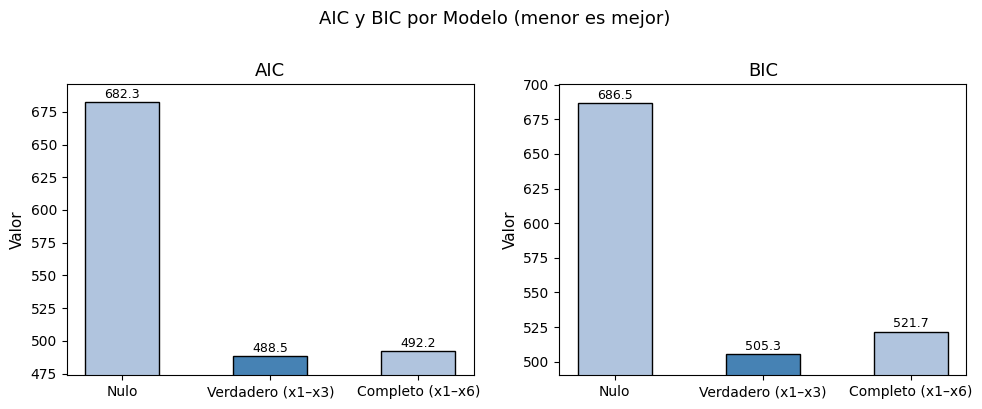

In [4]:
# ── Visualizar AIC y BIC entre modelos ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = ["Nulo", "Verdadero (x1–x3)", "Completo (x1–x6)"]

for ax, metric in zip(axes, ["AIC", "BIC"]):
    values = comparison[metric].values
    colors = ["steelblue" if v == values.min() else "lightsteelblue" for v in values]
    bars = ax.bar(models, values, color=colors, edgecolor="black", width=0.5)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel("Valor", fontsize=11)
    ax.set_ylim([values.min() * 0.97, values.max() * 1.02])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("AIC y BIC por Modelo (menor es mejor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Selección Forward por Pasos Usando AIC

La selección por pasos es una estrategia de búsqueda voraz que agrega (hacia adelante) o elimina (hacia atrás) predictores uno a la vez según un criterio — típicamente el AIC. `statsmodels` no tiene una función de selección por pasos incorporada, por lo que implementamos la **selección hacia adelante** manualmente.

**Algoritmo (selección hacia adelante):**
1. Comenzar con el modelo nulo (solo intercepto).
2. Para cada variable candidata que aún no esté en el modelo, ajustar el modelo con esa variable agregada.
3. Seleccionar la variable cuya adición produce el AIC más bajo.
4. Si el nuevo AIC es menor que el AIC del modelo actual, agregar la variable y repetir desde el paso 2.
5. Detener cuando ninguna adición de variable disminuya el AIC.

In [5]:
# ── Selección hacia adelante por pasos usando AIC ────────────────────
def forward_selection_aic(data, response, candidates):
    """
    Selección hacia adelante para regresión logística usando AIC.
    Retorna un DataFrame que registra cada paso.
    """
    selected    = []
    remaining   = list(candidates)
    current_aic = smf.logit(f"{response} ~ 1", data=data).fit(disp=False).aic
    log         = [{"Step": 0, "Variable Added": "(solo intercepto)", "AIC": current_aic}]

    while remaining:
        best_aic = current_aic
        best_var = None

        for var in remaining:
            formula = f"{response} ~ {' + '.join(selected + [var])}"
            aic_candidate = smf.logit(formula, data=data).fit(disp=False).aic
            if aic_candidate < best_aic:
                best_aic = aic_candidate
                best_var = var

        if best_var is None:
            break  # No se encontró mejora — detener

        selected.append(best_var)
        remaining.remove(best_var)
        current_aic = best_aic
        log.append({"Step": len(selected), "Variable Added": best_var, "AIC": current_aic})

    return pd.DataFrame(log), selected


candidates = ["x1", "x2", "x3", "x4", "x5", "x6"]
selection_log, final_vars = forward_selection_aic(df, "y", candidates)

print("Registro de Selección hacia Adelante:")
print(selection_log.round(2).to_string(index=False))
print(f"\nVariables seleccionadas: {final_vars}")

Registro de Selección hacia Adelante:
 Step    Variable Added    AIC
    0 (solo intercepto) 682.29
    1                x1 578.01
    2                x2 516.14
    3                x3 488.46

Variables seleccionadas: ['x1', 'x2', 'x3']


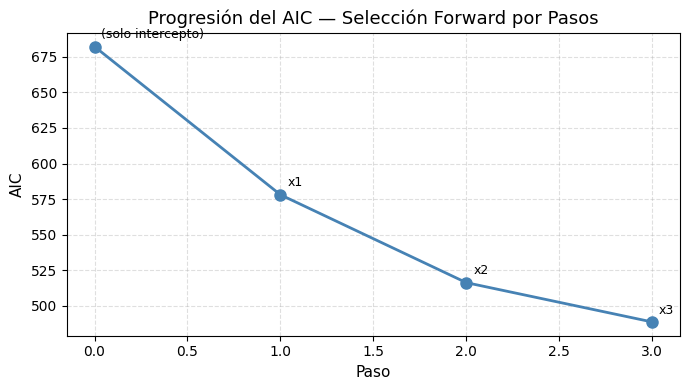

In [6]:
# ── Graficar la progresión del AIC durante la selección hacia adelante ────
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(selection_log["Step"], selection_log["AIC"],
        marker="o", color="steelblue", lw=2, markersize=8)

for _, row in selection_log.iterrows():
    ax.annotate(row["Variable Added"],
                xy=(row["Step"], row["AIC"]),
                xytext=(5, 6), textcoords="offset points", fontsize=9)

ax.set_xlabel("Paso", fontsize=11)
ax.set_ylabel("AIC", fontsize=11)
ax.set_title("Progresión del AIC — Selección Forward por Pasos", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 4. Validación Cruzada para Regresión Logística

Los criterios de información se calculan sobre los **datos de entrenamiento**, lo que significa que dependen de aproximaciones asintóticas y pueden no reflejar directamente el rendimiento fuera de muestra. La **validación cruzada** proporciona una estimación directa y empírica del error de generalización.

### Validación Cruzada de $k$ Pliegues

1. Dividir los datos en $k$ pliegues de tamaño aproximadamente igual.
2. Para cada pliegue $i = 1, \ldots, k$:
   - Usar los pliegues $\neq i$ como conjunto de entrenamiento.
   - Evaluar el modelo ajustado en el pliegue $i$ (el conjunto de validación).
3. Promediar las $k$ puntuaciones de validación para estimar la métrica de generalización.

La validación cruzada **estratificada** de $k$ pliegues preserva la proporción de clases en cada pliegue — recomendada para resultados binarios.

Opciones comunes: $k = 5$ o $k = 10$. Valores mayores de $k$ reducen el sesgo pero aumentan la varianza y el tiempo de cómputo.

In [7]:
# ── Validación cruzada de k pliegues para los tres modelos candidatos ─
X = df[["x1", "x2", "x3", "x4", "x5", "x6"]].values
X_true = df[["x1", "x2", "x3"]].values
y_arr  = df["y"].values

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

pipe_true = Pipeline([("scaler", StandardScaler()),
                      ("lr", LogisticRegression(C=1e6, max_iter=500))])
pipe_full = Pipeline([("scaler", StandardScaler()),
                      ("lr", LogisticRegression(C=1e6, max_iter=500))])

cv_auc_true = cross_val_score(pipe_true, X_true, y_arr, cv=cv, scoring="roc_auc")
cv_auc_full = cross_val_score(pipe_full, X,      y_arr, cv=cv, scoring="roc_auc")

print("Resultados de Validación Cruzada de 10 Pliegues (AUC):")
print(f"  Modelo verdadero (x1+x2+x3) : {cv_auc_true.mean():.4f} ± {cv_auc_true.std():.4f}")
print(f"  Modelo completo  (x1–x6)    : {cv_auc_full.mean():.4f} ± {cv_auc_full.std():.4f}")

Resultados de Validación Cruzada de 10 Pliegues (AUC):
  Modelo verdadero (x1+x2+x3) : 0.8443 ± 0.0291
  Modelo completo  (x1–x6)    : 0.8420 ± 0.0315


/var/folders/0p/0c9x6nl50w98gt5nnl1pq__w0000gn/T/ipykernel_8117/2637996901.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=labels, patch_artist=True, widths=0.4,


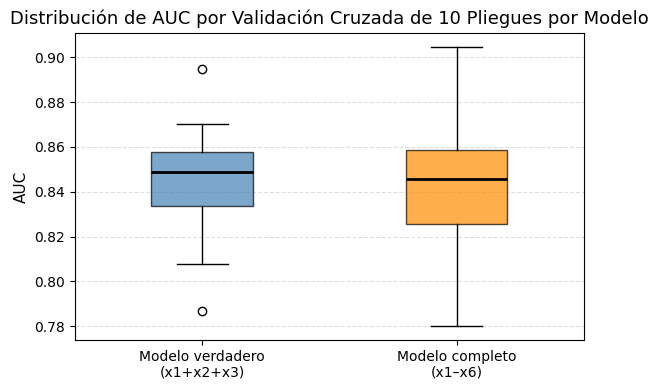

In [8]:
# ── Visualizar las distribuciones de AUC por validación cruzada (diagrama de caja) ─
fig, ax = plt.subplots(figsize=(6, 4))

data_box = [cv_auc_true, cv_auc_full]
labels   = ["Modelo verdadero\n(x1+x2+x3)", "Modelo completo\n(x1–x6)"]

bp = ax.boxplot(data_box, labels=labels, patch_artist=True, widths=0.4,
                medianprops={"color": "black", "lw": 2})

colors = ["steelblue", "darkorange"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("AUC", fontsize=11)
ax.set_title("Distribución de AUC por Validación Cruzada de 10 Pliegues por Modelo", fontsize=13)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Curva de Validación: Fuerza de la Regularización

Una **curva de validación** muestra cómo el rendimiento en entrenamiento y validación cruzada de un modelo cambian a medida que varía un hiperparámetro. A continuación examinamos el efecto del parámetro de regularización $C$ (inverso de la fuerza de regularización) sobre el AUC validado cruzadamente.

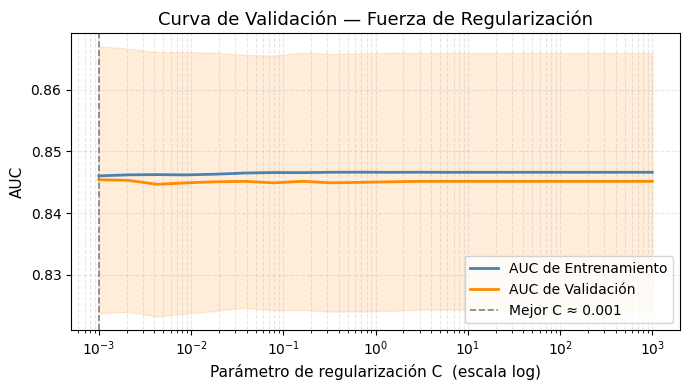

Mejor C por AUC de validación: 0.0010


In [9]:
# ── Curva de validación: fuerza de regularización C ───────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe_val = Pipeline([("scaler", StandardScaler()),
                     ("lr", LogisticRegression(max_iter=500, random_state=0))])

C_range = np.logspace(-3, 3, 20)

train_scores, val_scores = validation_curve(
    pipe_val, X_true, y_arr,
    param_name="lr__C",
    param_range=C_range,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=2),
    scoring="roc_auc",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))

ax.semilogx(C_range, train_mean, label="AUC de Entrenamiento",   color="steelblue",  lw=2)
ax.semilogx(C_range, val_mean,   label="AUC de Validación", color="darkorange", lw=2)
ax.fill_between(C_range, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="darkorange")

ax.axvline(C_range[val_mean.argmax()], color="gray", lw=1.2,
           linestyle="--", label=f"Mejor C ≈ {C_range[val_mean.argmax()]:.3f}")

ax.set_xlabel("Parámetro de regularización C  (escala log)", fontsize=11)
ax.set_ylabel("AUC", fontsize=11)
ax.set_title("Curva de Validación — Fuerza de Regularización", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

best_C = C_range[val_mean.argmax()]
print(f"Mejor C por AUC de validación: {best_C:.4f}")

## 5. Prueba de Razón de Verosimilitud (PRV) para Modelos Anidados

Cuando un modelo es un **caso especial** de otro (es decir, están *anidados*), la **Prueba de Razón de Verosimilitud** proporciona una prueba de hipótesis formal.

**Planteamiento:** Sea el Modelo 0 (restringido) anidado dentro del Modelo 1 (no restringido), con $k_0 < k_1$ parámetros.

$$H_0: \text{los parámetros adicionales en el Modelo 1 son todos cero}$$
$$H_1: \text{al menos un parámetro adicional es distinto de cero}$$

**Estadístico de prueba:**

$$LR = -2\left[\,\ell(\hat{\boldsymbol{\beta}}_0) - \ell(\hat{\boldsymbol{\beta}}_1)\,\right] = 2\left[\,\ell(\hat{\boldsymbol{\beta}}_1) - \ell(\hat{\boldsymbol{\beta}}_0)\,\right]$$

Bajo $H_0$, $LR \sim \chi^2(k_1 - k_0)$ asintóticamente.

Un valor $p$ pequeño proporciona evidencia de que los predictores adicionales en el Modelo 1 contribuyen significativamente al ajuste.

> **Nota:** La PRV solo es válida para modelos **anidados** ajustados en el **mismo conjunto de datos** con el **mismo método de estimación** (máxima verosimilitud). No puede usarse para comparar modelos no anidados.

In [10]:
# ── PRV: Modelo nulo vs. Modelo verdadero (x1 + x2 + x3) ──────────────
def likelihood_ratio_test(fit_restricted, fit_unrestricted):
    """
    Realiza una prueba de razón de verosimilitud comparando dos ajustes de
    regresión logística anidados con statsmodels.
    Retorna el estadístico LR, los grados de libertad y el valor p.
    """
    lr_stat = 2 * (fit_unrestricted.llf - fit_restricted.llf)
    df_diff = fit_unrestricted.df_model - fit_restricted.df_model
    p_value = stats.chi2.sf(lr_stat, df=df_diff)   # función de supervivencia = 1 - FDA
    return lr_stat, int(df_diff), p_value


# ── Prueba 1: Nulo  vs. Verdadero (agregando x1, x2, x3) ────────────
lr1, df1, p1 = likelihood_ratio_test(fit_null, fit_true)
print("PRV 1 — Modelo nulo vs. Modelo verdadero (x1+x2+x3):")
print(f"  Estadístico LR = {lr1:.4f}")
print(f"  Grados de libertad = {df1}")
print(f"  Valor p = {p1:.6f}\n")

# ── Prueba 2: Verdadero  vs. Completo (agregando x4, x5, x6) ─────────
lr2, df2, p2 = likelihood_ratio_test(fit_true, fit_full)
print("PRV 2 — Modelo verdadero (x1+x2+x3) vs. Modelo completo (x1–x6):")
print(f"  Estadístico LR = {lr2:.4f}")
print(f"  Grados de libertad = {df2}")
print(f"  Valor p = {p2:.6f}")

PRV 1 — Modelo nulo vs. Modelo verdadero (x1+x2+x3):
  Estadístico LR = 199.8313
  Grados de libertad = 3
  Valor p = 0.000000

PRV 2 — Modelo verdadero (x1+x2+x3) vs. Modelo completo (x1–x6):
  Estadístico LR = 2.2617
  Grados de libertad = 3
  Valor p = 0.519897


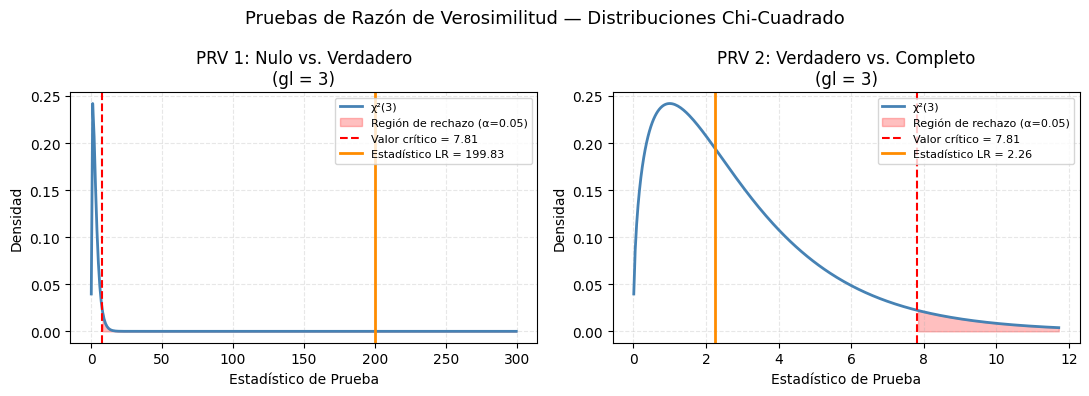

In [11]:
# ── Visualizar estadísticos LR con valores críticos chi-cuadrado ─────
alpha = 0.05
cv1 = stats.chi2.ppf(1 - alpha, df=df1)   # valor crítico para la prueba 1
cv2 = stats.chi2.ppf(1 - alpha, df=df2)   # valor crítico para la prueba 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, lr_stat, df_chi, cv, title in zip(
    axes,
    [lr1, lr2],
    [df1, df2],
    [cv1, cv2],
    ["PRV 1: Nulo vs. Verdadero\n(gl = 3)",
     "PRV 2: Verdadero vs. Completo\n(gl = 3)"],
):
    x_max = max(lr_stat, cv) * 1.5
    x = np.linspace(0.01, x_max, 300)
    y_chi = stats.chi2.pdf(x, df=df_chi)

    ax.plot(x, y_chi, lw=2, color="steelblue", label=f"χ²({df_chi})")

    # Región de rechazo
    x_rej = x[x >= cv]
    ax.fill_between(x_rej, stats.chi2.pdf(x_rej, df=df_chi),
                    alpha=0.25, color="red", label=f"Región de rechazo (α=0.05)")

    ax.axvline(cv,      color="red",       lw=1.5, linestyle="--", label=f"Valor crítico = {cv:.2f}")
    ax.axvline(lr_stat, color="darkorange", lw=2,   linestyle="-",  label=f"Estadístico LR = {lr_stat:.2f}")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Estadístico de Prueba", fontsize=10)
    ax.set_ylabel("Densidad", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.3)

fig.suptitle("Pruebas de Razón de Verosimilitud — Distribuciones Chi-Cuadrado", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# ── Resumen de todos los resultados de selección de modelos ───────────
cv_null = cross_val_score(
    LogisticRegression(C=1e6, max_iter=500),
    np.ones((len(y_arr), 1)),   # columna constante → modelo nulo (solo intercepto)
    y_arr,
    cv=StratifiedKFold(5, shuffle=True, random_state=3),
    scoring="roc_auc",
)

# Reutilizar los cv_auc_true y cv_auc_full calculados previamente
summary = pd.DataFrame({
    "Model"         : ["Nulo", "Verdadero (x1+x2+x3)", "Completo (x1–x6)"],
    "Parameters (k)": [1, 4, 7],
    "Log-Likelihood": [round(fit_null.llf, 2), round(fit_true.llf, 2), round(fit_full.llf, 2)],
    "AIC"           : [round(fit_null.aic, 2),  round(fit_true.aic, 2),  round(fit_full.aic, 2)],
    "BIC"           : [round(fit_null.bic, 2),  round(fit_true.bic, 2),  round(fit_full.bic, 2)],
    "CV-AUC (mean)" : [f"{cv_null.mean():.4f}",
                       f"{cv_auc_true.mean():.4f}",
                       f"{cv_auc_full.mean():.4f}"],
})

print("Resumen de Selección de Modelos:")
print(summary.to_string(index=False))

Resumen de Selección de Modelos:
               Model  Parameters (k)  Log-Likelihood    AIC    BIC CV-AUC (mean)
                Nulo               1         -340.15 682.29 686.51        0.5000
Verdadero (x1+x2+x3)               4         -240.23 488.46 505.32        0.8443
    Completo (x1–x6)               7         -239.10 492.20 521.70        0.8420


## Conclusiones Clave

1. El **AIC y el BIC** son criterios de forma cerrada rápidos basados en el logaritmo de la verosimilitud. El BIC penaliza la complejidad más fuertemente para $n$ grande y tiende a seleccionar modelos más parsimoniosos. Ambos se calculan sobre los datos de entrenamiento y dependen de la teoría asintótica.

2. La **selección hacia adelante por pasos** con AIC es una heurística práctica para el cribado automatizado de variables, pero no garantiza encontrar el subconjunto globalmente óptimo y debe interpretarse con cautela.

3. La **validación cruzada** proporciona una estimación empírica del rendimiento fuera de muestra sin depender de aproximaciones asintóticas. La validación cruzada estratificada de $k$ pliegues es la opción estándar para resultados binarios.

4. La **curva de validación** revela el compromiso sesgo-varianza para un hiperparámetro: $C$ pequeño (regularización fuerte) puede producir subajuste; $C$ grande (regularización débil) puede producir sobreajuste.

5. La **Prueba de Razón de Verosimilitud** ofrece una prueba de hipótesis formal para comparar modelos anidados. Un resultado significativo (valor $p$ pequeño) significa que los predictores adicionales mejoran el ajuste más allá de lo esperado por azar. No puede usarse para modelos no anidados.